## 1. Import dependencies

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gyanendramohanpatel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/gyanendramohanpatel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Importing the dataset
### 1.1 Load dataframe

In [8]:
# Load the SMS Spam Collection dataset
filepath = "SMSSpamCollection"
df = pd.read_csv(filepath, sep="\t", header=None, names=["label", "message"])
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 1.2 Drop uneccessary columns

In [9]:
# There are only 2 columns, so nothing to drop.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### 1.3 Check balance

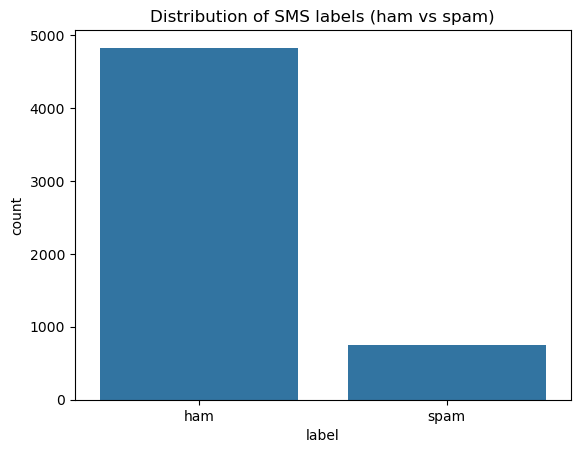

label
ham     4825
spam     747
Name: count, dtype: int64


In [10]:
# Plot the distribution of 'ham' vs 'spam'
sns.countplot(x='label', data=df)
plt.title("Distribution of SMS labels (ham vs spam)")
plt.show()

print(df['label'].value_counts())


### 1.4 Trim size of dataframe (optional)

In [11]:
print("Dataset shape:", df.shape)
# The dataset has about 5500 rows, which is perfectly fine to process fully without trimming.


Dataset shape: (5572, 2)


## 2. Cleaning and pre-processing the data
### 2.1 Inspect data

In [12]:
# Checking for missing values
print(df.isnull().sum())

# Convert labels to numerical scores: spam=1, ham=0
df['score'] = df['label'].map({'spam': 1, 'ham': 0})


label      0
message    0
dtype: int64


### 2.3 Preprocessing all messages

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub('<.*?>', '', text) # Remove HTML tags 
    text = re.sub('[^a-zA-Z]', ' ', text) # Remove non-alphabetic
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(preprocess_text)
df[['message', 'clean_message']].head()


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


## 3. Analyze the data
### 3.1 Inspect some data

In [14]:
df.sample(5)[['message', 'clean_message', 'label']]


,message,clean_message,label
779,Happy New year my dear brother. I really do mi...,happy new year dear brother really miss got nu...,ham
970,It wont b until 2.15 as trying 2 sort house ou...,wont b trying sort house ok,ham
3806,Dude while were makin those weirdy brownies my...,dude makin weirdy brownie sister made awesome ...,ham
2742,I don't know u and u don't know me. Send CHAT ...,know u u know send chat let find p msg rcvd hg...,spam
3012,"Hm good morning, headache anyone? :-)",hm good morning headache anyone,ham


### 3.2 Analyze most common words

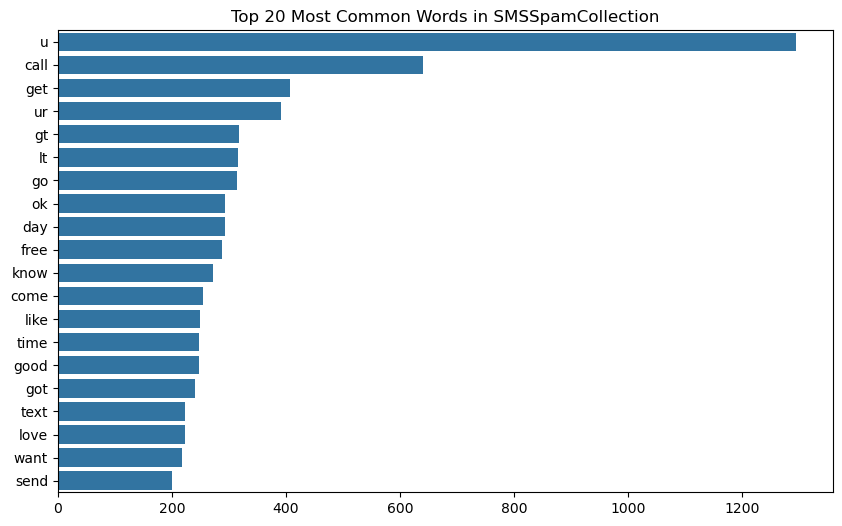

In [15]:
corpus = ' '.join(df['clean_message'].tolist())
word_freq = Counter(corpus.split())
common_words = word_freq.most_common(20)

words, counts = zip(*common_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Common Words in SMSSpamCollection")
plt.show()


### 3.3 Word cloud of most common pos (Spam) words

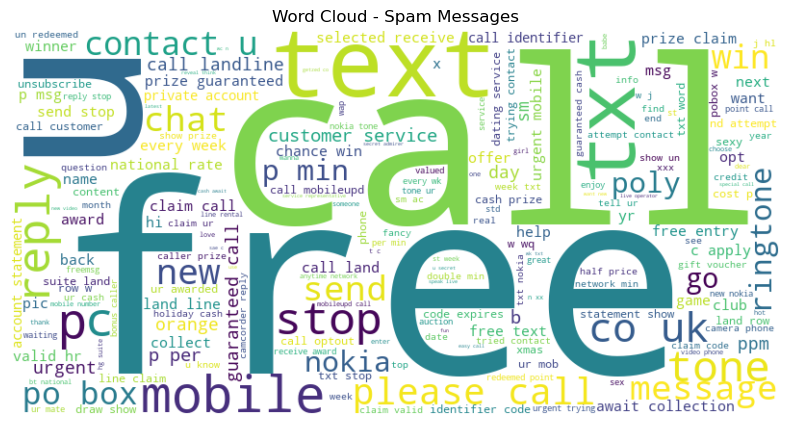

In [16]:
spam_corpus = ' '.join(df[df['label'] == 'spam']['clean_message'].tolist())
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Spam Messages")
plt.show()


### 3.4 Word cloud of most common neg (Ham) words

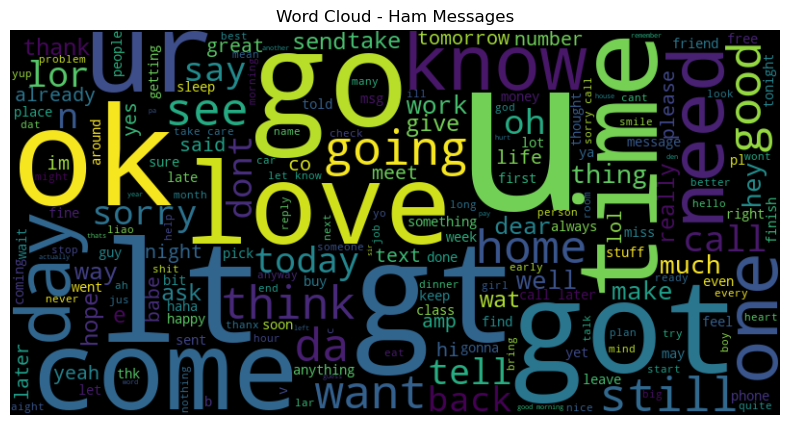

In [17]:
ham_corpus = ' '.join(df[df['label'] == 'ham']['clean_message'].tolist())
wordcloud_ham = WordCloud(width=800, height=400, background_color='black').generate(ham_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Ham Messages")
plt.show()


### 3.5 Comments

In [18]:
print("Spam messages heavily feature words representing urgency and offers like 'call', 'free', 'txt', 'mobile', and 'claim'.")
print("Ham (regular) messages feature conversational words like 'u', 'go', 'get', 'come', 'ok'.")


Spam messages heavily feature words representing urgency and offers like 'call', 'free', 'txt', 'mobile', and 'claim'.
Ham (regular) messages feature conversational words like 'u', 'go', 'get', 'come', 'ok'.


## 4. Split the data into train & test

In [19]:
X = df['clean_message']
y = df['score']

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (4457, 5000)
Testing shape: (1115, 5000)


### 4.2 Comments

In [20]:
print("Data maps text features -> TF-IDF vectors representing 5000 top features.")
print("The data is split 80% (training) / 20% (testing).")


Data maps text features -> TF-IDF vectors representing 5000 top features.
The data is split 80% (training) / 20% (testing).


## 7. Naive Bayes

Accuracy: 0.9730941704035875

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



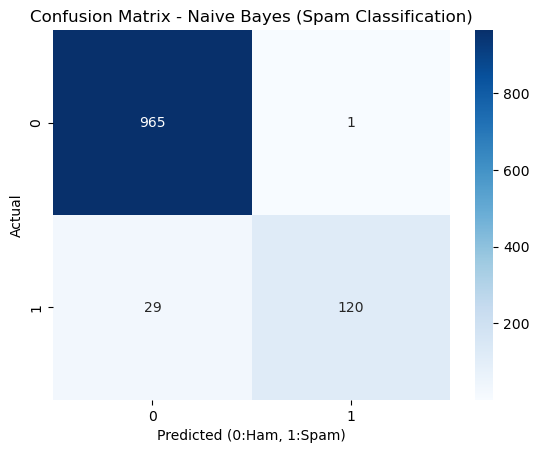

In [21]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted (0:Ham, 1:Spam)")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes (Spam Classification)")
plt.show()


## 8. Test the Model

In [22]:
# Test on some sample custom SMS messages
custom_sms = [
    "WINNER! claim your free iPhone now by calling exactly this number: 555-1234",
    "Hey hun, want to grab lunch around 1pm today? Let me know",
    "URGENT: Your bank account has been locked. Click here to verify your identity.",
    "Can you pick up milk on your way back home? Thanks"
]

custom_df = pd.DataFrame({'message': custom_sms})
custom_df['clean_message'] = custom_df['message'].apply(preprocess_text)
custom_vec = vectorizer.transform(custom_df['clean_message'])

custom_df['predicted_score'] = nb_classifier.predict(custom_vec)
custom_df['predicted_class'] = custom_df['predicted_score'].map({1: 'spam', 0: 'ham'})

display(custom_df[['message', 'predicted_class']])


,message,predicted_class
0,WINNER! claim your free iPhone now by calling ...,spam
1,"Hey hun, want to grab lunch around 1pm today? ...",ham
2,URGENT: Your bank account has been locked. Cli...,spam
3,Can you pick up milk on your way back home? Th...,ham
